In [8]:
from function_lib import *

In [9]:
# ----------------- config -----------------
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

# ----------------- results ----------------
total_result  = {}
# =========================================================
# main loop over seeds
# =========================================================

# ----- build Z (all feasible z) only once -----
sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
model_list = ["DIO-0.00000001", "DIO-0.1", "DIO-10", "DIO-100", "DIO-1000", "DIO-10000", "DIO-100000", "DIO-10000000"]

for model_type in model_list:
    regret_result = []
    parame_result = []

    if "DIO-" in model_type:
        eta = float(model_type.split("-")[1])
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    print(eta)
    
    solver = None  # will build once on the first iteration

    for seed in tqdm(range(n_simulation),
                     desc="Running simulations",
                     colour="green"):

        # ---- reproducibility ----
        random.seed(seed)
        np.random.seed(seed)

        # ---- data for this seed ----
        x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
            base, n_instance, input_dim, deg, noise, grid_width, seed
        )
        
        # ---- build solver only once (reuse the same model) ----
        if solver is None:
            solver = DIOECPParam(
                N=x_train.shape[0],       # must be constant across seeds
                d_x=x_train.shape[1],
                d_c=y_train.shape[1],
                Z=sols,                   # Z is fixed set of feasible decisions
                eta=eta
            )

        # ---- solve training problem for this seed ----
        res = solver.solve(x_train, y_train, verbose=False)

        # ---- evaluate regret on test set ----
        # B is already stored in solver.B after solve(), so B argument is optional
        eval_res = solver.evaluate_regret(
            x_test, y_test, return_per_sample=False
        )

        regret_result.append(eval_res["avg_regret"])
        parame_result.append(res["B"])

    # save results for this model type
    total_result[model_type] = {
        "regret": regret_result,
        "params": parame_result
    }
    # ==================================================
    # CRITICAL FIX: Clean up memory before next model!
    # ==================================================
    if solver is not None:
        solver.M.dispose()  # Release Mosek C-memory immediately
        del solver          # Delete Python object
    
    gc.collect()            # Force Python Garbage Collector

    process = psutil.Process(os.getpid())
    print(f"Python process RAM: {process.memory_info().rss/1024/1024/1024:.3f} GB")

# Save the result to pickle file
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)   # create directory if not exist
file_path = os.path.join(save_path, f"Shortest_path_DIO_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl")
with open(file_path, "wb") as f:
    pickle.dump(total_result, f)

def print_memory():
    mem = psutil.virtual_memory()
    print(f"Available: {mem.available/1024/1024/1024:.2f} GB")
    print(f"Used:      {(mem.total - mem.available)/1024/1024/1024:.2f} GB")
    print(f"Percent:   {mem.percent}%")

print_memory()

1e-08


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 54.84it/s]


Python process RAM: 0.236 GB
0.1


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 50.76it/s]


Python process RAM: 0.236 GB
10.0


...

Python process RAM: 0.236 GB
100000.0


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 43.04it/s]


Python process RAM: 0.237 GB
10000000.0


Running simulations: 100%|██████████| 30/30 [00:00<00:00, 42.25it/s]

Python process RAM: 0.235 GB
Available: 15.88 GB
Used:      15.87 GB
Percent:   50.0%


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_3060\284684682.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


         Model     Mean      Std    VaR90   CVaR90
DIO-0.00000001 0.109153 0.054161 0.199532 0.213948
       DIO-0.1 0.107315 0.053305 0.171451 0.213948
        DIO-10 0.107315 0.053305 0.171451 0.213948
       DIO-100 0.107315 0.053305 0.171451 0.213948
      DIO-1000 0.107315 0.053305 0.171451 0.213948
     DIO-10000 0.107315 0.053305 0.171451 0.213948
    DIO-100000 0.107315 0.053305 0.171451 0.213948
  DIO-10000000 0.107315 0.053305 0.171451 0.213948


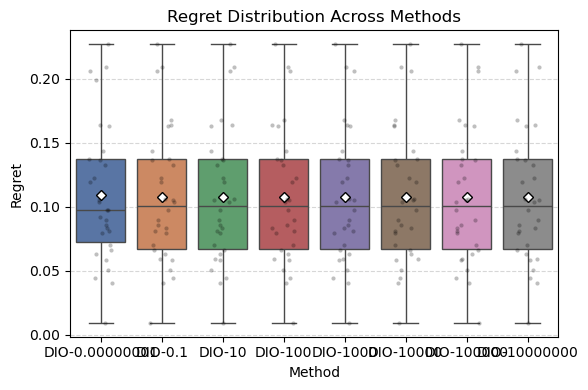

In [10]:
# Compute stats for the LST model
# regrets = total_result["LST-0.1"]["regret"]

# mean, std, var90, cvar90 = compute_stats(regrets)

# print(f"Mean    : {mean:.6f}")
# print(f"Std     : {std:.6f}")
# print(f"VaR 90  : {var90:.6f}")
# print(f"CVaR 90 : {cvar90:.6f}")
rows = []
for model_type in model_list:
    regrets = total_result[model_type]["regret"]
    mean, std, var90, cvar90 = compute_stats(regrets)

    rows.append({
        "Model": model_type,
        "Mean": mean,
        "Std": std,
        "VaR90": var90,
        "CVaR90": cvar90
    })

# convert to DataFrame
df = pd.DataFrame(rows)

# nicely formatted print
print(df.to_string(index=False, float_format="%.6f"))


# Collect regret distributions across all model types
df_list = []
for model_type, data in total_result.items():
    df_list.append(pd.DataFrame({
        "method": [model_type] * len(data["regret"]),
        "regret": data["regret"]
    }))

df = pd.concat(df_list, ignore_index=True)

# Academic color palette
palette = sns.color_palette("deep")
unique_methods = sorted(df["method"].unique())
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(unique_methods)}

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution Across Methods", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "dio_regret_comparison.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [11]:
# seed = 1
# x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed)

# # Example usage:

# sols, edges, G = generate_all_feasible_solutions(grid_width=5)
# print("Number of edges:", len(edges))
# print("Number of feasible s->t paths:", len(sols))
# print("First solution vector:", sols[0])

# # pick any solution
# vec = sols[10]
# # draw
# draw_solution(G, edges, vec, grid_width=5, cost=y_train[0])
# solver = LSTECPParam(
#     N=x_train.shape[0],
#     d_x=x_train.shape[1],
#     d_c=y_train.shape[1],
#     Z=sols,
#     eta=0.5
# )

# X_run = x_train   # shape (N, d_x)
# C_run = y_train   # shape (N, d_c)

# res = solver.solve(X_run, C_run, verbose=False)
# eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=True)
# print("Avg regret:", eval_res["avg_regret"])
# # print("Per-sample regret:", eval_res["regret_per_sample"])
